In [22]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

load_dotenv()

True

In [23]:
class Sentiment(BaseModel):
    sentiment : Literal['positive', 'negative'] = Field(description = 'Sentiment of the Review')


class DiagnosisSchema(BaseModel):
    issue_type : Literal['UX', 'Performance', 'Bug', 'Support', 'Other'] = Field(description = 'The issue type for the review')
    tone : Literal['Angry', 'Frustrated', 'Calm', 'disappointed'] = Field(description = 'The emotion behind the review')
    urgency: Literal['Low', 'Medium', 'High'] = Field(discription = 'How urgent the request should be processed')

model = ChatOpenAI(model = 'gpt-4o-mini')

structured_model = model.with_structured_output(Sentiment)
structured_model_2 = model.with_structured_output(DiagnosisSchema)

/var/folders/6s/gkjsdfrj1cv0p9_krbp5k92m0000gn/T/ipykernel_64163/1330860205.py:8: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'discription'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  urgency: Literal['Low', 'Medium', 'High'] = Field(discription = 'How urgent the request should be processed')


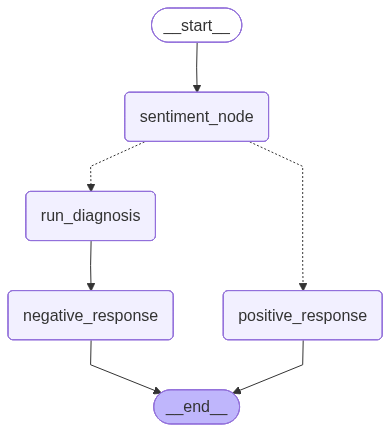

In [24]:
class SentimentGraph(TypedDict):
    review : str
    sentiment : Literal['positive', 'negative']
    diagnosis : dict
    response : str

graph = StateGraph(SentimentGraph)

def find_sentiment(state: SentimentGraph):
    review = state['review']

    prompt = f'Analyse the review and tell the sentiment of the {review}'

    response = structured_model.invoke(prompt)

    return {'sentiment' : response.sentiment}

def positive_response(state : SentimentGraph):
    prompt = f"Provide a warm response based on the reponse from the user {state['review']}"

    response = model.invoke(prompt).content

    return {'response' : response}

def negative_response(state : SentimentGraph):
    diagnosis = state['diagnosis']
    prompt = f"You are a helpful assistant, user provided this review \n {state['review']} \n the user had {diagnosis['tone']} tone and {diagnosis['issue_type']} issue type and {diagnosis['urgency']} urgency"

    response = model.invoke(prompt).content

    return {'response' : response}

def run_diagnosis(state : SentimentGraph):
    prompt = f"Diagnose this negative response and return the output in issue_type, tone and urgency: {state['review']}"

    response = structured_model_2.invoke(prompt)

    # since the response is a json object and the disgnosis is a dictionary, then we have to convert this into dictionary using the model_dump()
    return {'diagnosis' : response.model_dump()}

def check_sentiment(state : SentimentGraph) -> Literal['positive_response', 'run_diagnosis']:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

graph.add_node('sentiment_node', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('negative_response', negative_response)
graph.add_node('run_diagnosis', run_diagnosis)

graph.add_edge(START, 'sentiment_node')
graph.add_conditional_edges('sentiment_node', check_sentiment)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('positive_response', END)
graph.add_edge('negative_response', END)


workflow = graph.compile()

workflow

In [25]:
initial_state = {
    'review' : 'The product quality was really bad, the phone display is too small and the reposne time is also very late. I want to initiate refund'
}

response = workflow.invoke(initial_state)

In [26]:
response

{'review': 'The product quality was really bad, the phone display is too small and the reposne time is also very late. I want to initiate refund',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'Frustrated', 'urgency': 'High'},
 'response': "It sounds like you're experiencing some frustrations with the product you received. Here’s a possible response you could use to request a refund for your purchase:\n\n---\n\nSubject: Request for Refund\n\nDear [Customer Service/Support Team],\n\nI hope this message finds you well. I am writing to formally request a refund for the [product name/model] that I purchased on [purchase date]. \n\nUnfortunately, I have encountered several issues with the product that have left me quite dissatisfied. Specifically, the display is too small for my needs, and the response time is notably slow, which makes it difficult to use effectively. \n\nGiven these quality concerns, I would like to initiate the refund process as soon as possible. P